# Predictor comparison — AlphaMissense vs CADD vs REVEL

Benchmarks three pathogenicity predictors on 292 CFTR variants with CFTR2 ground truth labels.

Requires `cftr2_results_annotated.csv` from `alphamissense.ipynb` and `All_Variants_VEP.Gene.vcf`.

In [2]:
import re
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

## Step 1. Load the 292 labelled variants

In [3]:
result = pd.read_csv("cftr2_results_annotated.csv")

binary = result[
    result["determination_2026"].isin(["CF-causing", "Non CF-causing"]) &
    result["am_pathogenicity"].notna()
].copy()
binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

print(f"Labelled variants: {len(binary)}")
print(f"CF-causing    : {binary['label'].sum()}")
print(f"Non CF-causing: {(binary['label'] == 0).sum()}")

Labelled variants: 292
CF-causing    : 253
Non CF-causing: 39


## Step 2. Extract genomic coordinates from VCF

CADD needs chr, pos, ref, alt — not protein names.

In [4]:
protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')

variant_coords = {}

with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        if len(parts) < 5:
            continue
        chrom, pos, _, ref, alt = parts[0], parts[1], parts[2], parts[3], parts[4]
        match = protein_pattern.search(line)
        if match:
            name = match.group(1)
            if name not in variant_coords:
                variant_coords[name] = {"chrom": chrom, "pos": pos, "ref": ref, "alt": alt}

binary["chrom"] = binary["variant"].map({k: v["chrom"] for k, v in variant_coords.items()})
binary["pos"]   = binary["variant"].map({k: v["pos"]   for k, v in variant_coords.items()})
binary["ref"]   = binary["variant"].map({k: v["ref"]   for k, v in variant_coords.items()})
binary["alt"]   = binary["variant"].map({k: v["alt"]   for k, v in variant_coords.items()})

print(f"Coordinates found: {binary['pos'].notna().sum()} / {len(binary)}")
print(binary[["variant", "chrom", "pos", "ref", "alt"]].head())

Coordinates found: 292 / 292
    variant chrom        pos ref alt
0  Ser13Phe     7  117480132   C   T
1  Arg31Cys     7  117504290   C   T
6  Trp57Gly     7  117509038   T   G
7  Pro67Leu     7  117509069   C   T
9  Arg75Gln     7  117509093   G   A


In [5]:
CADD_URL = "https://cadd.gs.washington.edu/api/v1.0/{chrom}-{pos}-{ref}-{alt}"

def get_cadd_score(chrom, pos, ref, alt) -> float | None:
    try:
        url = CADD_URL.format(chrom=chrom, pos=pos, ref=ref, alt=alt)
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data and len(data) > 1:
            return float(data[1][5])  # PHRED score
        return None
    except Exception:
        return None

cadd_scores = []
for i, row in binary.iterrows():
    score = get_cadd_score(row["chrom"], row["pos"], row["ref"], row["alt"])
    cadd_scores.append(score)
    if len(cadd_scores) % 20 == 0:
        print(f"  {len(cadd_scores)} / {len(binary)} done")
    time.sleep(0.3)

binary["cadd_score"] = cadd_scores
print(f"\nCADD scored: {binary['cadd_score'].notna().sum()} / {len(binary)}")
print(binary[["variant", "cadd_score"]].head())


  20 / 292 done
  40 / 292 done
  60 / 292 done
  80 / 292 done
  100 / 292 done
  120 / 292 done
  140 / 292 done
  160 / 292 done
  180 / 292 done
  200 / 292 done
  220 / 292 done
  240 / 292 done
  260 / 292 done
  280 / 292 done

CADD scored: 0 / 292
    variant cadd_score
0  Ser13Phe       None
1  Arg31Cys       None
6  Trp57Gly       None
7  Pro67Leu       None
9  Arg75Gln       None


In [7]:
resp = requests.get(
    "https://cadd.gs.washington.edu/api/v1.0/GRCh38-v1.7/7:117480132_C_T",
    timeout=10
)
print(resp.status_code)
print(resp.text[:500])


200
[{"Alt":"T","Chrom":"7","PHRED":"29.4","Pos":"117480132","RawScore":"5.238939","Ref":"C"}]



In [8]:
CADD_URL = "https://cadd.gs.washington.edu/api/v1.0/GRCh38-v1.7/{chrom}:{pos}_{ref}_{alt}"

def get_cadd_score(chrom, pos, ref, alt) -> float | None:
    try:
        url = CADD_URL.format(chrom=chrom, pos=pos, ref=ref, alt=alt)
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data and len(data) > 0:
            return float(data[0]["PHRED"])
        return None
    except Exception:
        return None

cadd_scores = []
for i, row in binary.iterrows():
    score = get_cadd_score(row["chrom"], row["pos"], row["ref"], row["alt"])
    cadd_scores.append(score)
    if len(cadd_scores) % 20 == 0:
        print(f"  {len(cadd_scores)} / {len(binary)} done")
    time.sleep(0.3)

binary["cadd_score"] = cadd_scores
print(f"\nCADD scored: {binary['cadd_score'].notna().sum()} / {len(binary)}")
print(binary[["variant", "cadd_score"]].head())


  20 / 292 done
  40 / 292 done
  60 / 292 done
  80 / 292 done
  100 / 292 done
  120 / 292 done
  140 / 292 done
  160 / 292 done
  180 / 292 done
  200 / 292 done
  220 / 292 done
  240 / 292 done
  260 / 292 done
  280 / 292 done

CADD scored: 286 / 292
    variant  cadd_score
0  Ser13Phe        29.4
1  Arg31Cys        28.1
6  Trp57Gly        26.0
7  Pro67Leu        26.7
9  Arg75Gln        29.7


AlphaMissense AUC : 0.946
CADD AUC          : 0.776
Variants used     : 286


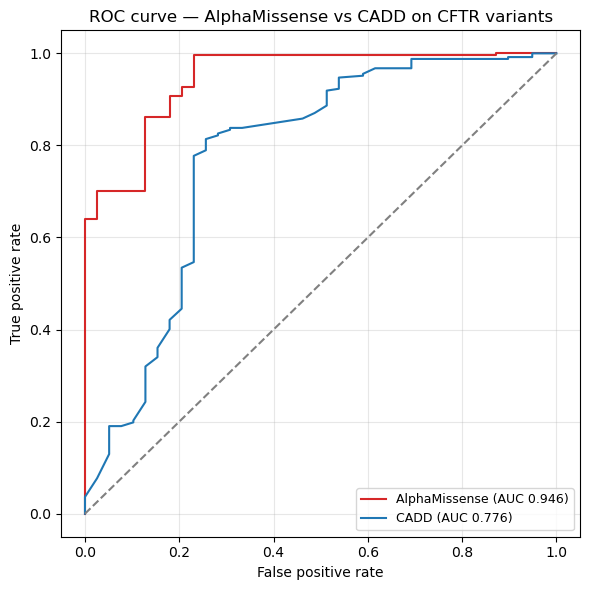

In [9]:
compare = binary[binary["cadd_score"].notna()].copy()

am_auc = roc_auc_score(compare["label"], compare["am_pathogenicity"])
cadd_auc = roc_auc_score(compare["label"], compare["cadd_score"])

print(f"AlphaMissense AUC : {am_auc:.3f}")
print(f"CADD AUC          : {cadd_auc:.3f}")
print(f"Variants used     : {len(compare)}")

# ROC curves
fig, ax = plt.subplots(figsize=(6, 6))

for name, scores, color in [
    ("AlphaMissense", compare["am_pathogenicity"], "#d62728"),
    ("CADD", compare["cadd_score"], "#1f77b4"),
]:
    fpr, tpr, _ = roc_curve(compare["label"], scores)
    auc = roc_auc_score(compare["label"], scores)
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC {auc:.3f})")

ax.plot([0,1],[0,1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — AlphaMissense vs CADD on CFTR variants")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as f:
    for line in f:
        if "REVEL" in line and line.startswith("##"):
            print(line.strip())
            break


In [15]:
SIFT_INDEX = 31
POLYPHEN_INDEX = 32

csq_pattern = re.compile(r'CSQ=([^;]+)')
protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')

variant_scores = {}

with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        csq_match = csq_pattern.search(line)
        if not csq_match:
            continue
        for transcript in csq_match.group(1).split(","):
            fields = transcript.split("|")
            if len(fields) <= POLYPHEN_INDEX:
                continue
            prot_match = protein_pattern.search(fields[11])
            if not prot_match:
                continue
            name = prot_match.group(1)
            sift = fields[SIFT_INDEX]
            polyphen = fields[POLYPHEN_INDEX]
            if name not in variant_scores and sift and polyphen:
                variant_scores[name] = {"sift": sift, "polyphen": polyphen}

print(f"Variants with SIFT/PolyPhen: {len(variant_scores)}")
print(list(variant_scores.items())[:3])


Variants with SIFT/PolyPhen: 2473
[('Ser13Phe', {'sift': 'deleterious_low_confidence(0)', 'polyphen': 'probably_damaging(0.999)'}), ('Arg31Cys', {'sift': 'deleterious_low_confidence(0)', 'polyphen': 'possibly_damaging(0.673)'}), ('Arg31Leu', {'sift': 'deleterious_low_confidence(0)', 'polyphen': 'benign(0.136)'})]


Variants with all four scores: 286

AlphaMissense   AUC: 0.946
CADD            AUC: 0.776
PolyPhen        AUC: 0.826
SIFT            AUC: 0.678


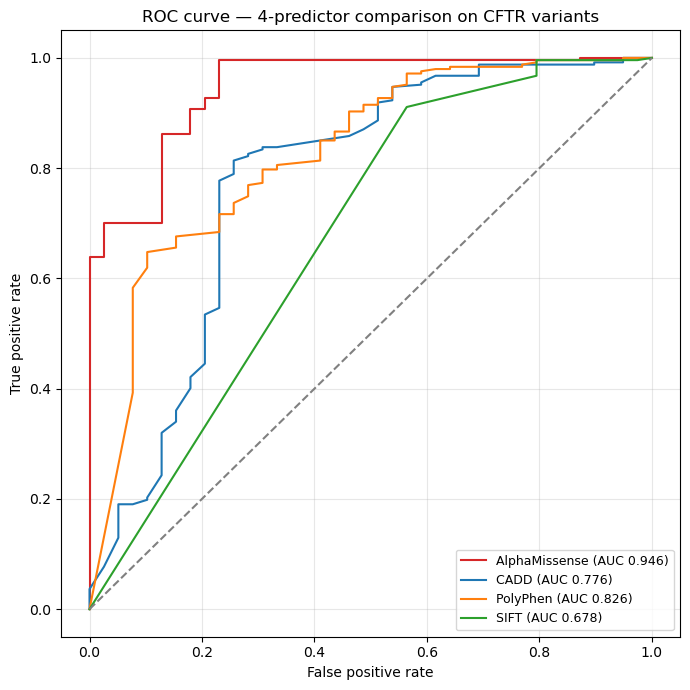

In [16]:
import re as re2

def parse_sift(s: str) -> float | None:
    m = re2.search(r'\(([0-9.]+)\)', s)
    if m:
        return 1 - float(m.group(1))  # invert: lower SIFT = more damaging
    return None

def parse_polyphen(s: str) -> float | None:
    m = re2.search(r'\(([0-9.]+)\)', s)
    return float(m.group(1)) if m else None

binary["sift_score"] = binary["variant"].map(
    {k: parse_sift(v["sift"]) for k, v in variant_scores.items()}
)
binary["polyphen_score"] = binary["variant"].map(
    {k: parse_polyphen(v["polyphen"]) for k, v in variant_scores.items()}
)

compare = binary[
    binary["cadd_score"].notna() &
    binary["sift_score"].notna() &
    binary["polyphen_score"].notna()
].copy()

print(f"Variants with all four scores: {len(compare)}")
print()

predictors = {
    "AlphaMissense": ("am_pathogenicity", "#d62728"),
    "CADD":          ("cadd_score",       "#1f77b4"),
    "PolyPhen":      ("polyphen_score",   "#ff7f0e"),
    "SIFT":          ("sift_score",       "#2ca02c"),
}

fig, ax = plt.subplots(figsize=(7, 7))
for name, (col, color) in predictors.items():
    fpr, tpr, _ = roc_curve(compare["label"], compare[col])
    auc = roc_auc_score(compare["label"], compare[col])
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC {auc:.3f})")
    print(f"{name:15} AUC: {auc:.3f}")

ax.plot([0,1],[0,1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — 4-predictor comparison on CFTR variants")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_4way.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 5. Precision-recall curves

ROC curves are optimistic on imbalanced data. The validation set is 253 CF-causing vs 39 Non CF-causing. Precision-recall curves give a more honest picture of how each predictor performs at identifying the minority class.

AlphaMissense   Average Precision: 0.990
CADD            Average Precision: 0.939
PolyPhen        Average Precision: 0.959
SIFT            Average Precision: 0.909


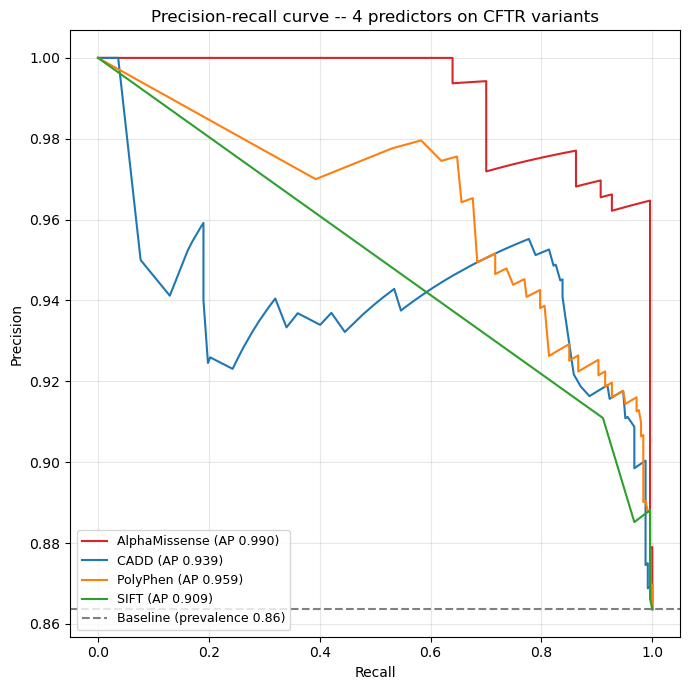

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

predictors = {
    "AlphaMissense": ("am_pathogenicity", "#d62728"),
    "CADD":          ("cadd_score",       "#1f77b4"),
    "PolyPhen":      ("polyphen_score",   "#ff7f0e"),
    "SIFT":          ("sift_score",       "#2ca02c"),
}

fig, ax = plt.subplots(figsize=(7, 7))

for name, (col, color) in predictors.items():
    precision, recall, _ = precision_recall_curve(compare["label"], compare[col])
    ap = average_precision_score(compare["label"], compare[col])
    ax.plot(recall, precision, color=color, label=f"{name} (AP {ap:.3f})")
    print(f"{name:15} Average Precision: {ap:.3f}")

baseline = compare["label"].mean()
ax.axhline(baseline, linestyle="--", color="grey", label=f"Baseline (prevalence {baseline:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curve -- 4 predictors on CFTR variants")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_4way.png", dpi=150, bbox_inches="tight")
plt.show()

In [2]:
import re
import numpy as np
import pandas as pd
import requests
import time
from scipy import stats
from sklearn.metrics import roc_auc_score

result = pd.read_csv("cftr2_results_annotated.csv")
binary = result[
    result["determination_2026"].isin(["CF-causing", "Non CF-causing"]) &
    result["am_pathogenicity"].notna()
].copy()
binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')
csq_pattern = re.compile(r'CSQ=([^;]+)')
variant_coords = {}
variant_scores = {}

with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        if len(parts) < 5:
            continue
        chrom, pos, _, ref, alt = parts[0], parts[1], parts[2], parts[3], parts[4]
        pm = protein_pattern.search(line)
        if pm and pm.group(1) not in variant_coords:
            variant_coords[pm.group(1)] = {"chrom": chrom, "pos": pos, "ref": ref, "alt": alt}
        csq_match = csq_pattern.search(line)
        if csq_match:
            for transcript in csq_match.group(1).split(","):
                fields = transcript.split("|")
                if len(fields) <= 32:
                    continue
                pm2 = protein_pattern.search(fields[11])
                if pm2 and pm2.group(1) not in variant_scores and fields[31] and fields[32]:
                    variant_scores[pm2.group(1)] = {"sift": fields[31], "polyphen": fields[32]}

def parse_sift(s):
    m = re.search(r'\(([0-9.]+)\)', s)
    return 1 - float(m.group(1)) if m else None

def parse_polyphen(s):
    m = re.search(r'\(([0-9.]+)\)', s)
    return float(m.group(1)) if m else None

binary["chrom"] = binary["variant"].map({k: v["chrom"] for k, v in variant_coords.items()})
binary["pos"]   = binary["variant"].map({k: v["pos"]   for k, v in variant_coords.items()})
binary["ref"]   = binary["variant"].map({k: v["ref"]   for k, v in variant_coords.items()})
binary["alt"]   = binary["variant"].map({k: v["alt"]   for k, v in variant_coords.items()})
binary["sift_score"]     = binary["variant"].map({k: parse_sift(v["sift"]) for k, v in variant_scores.items()})
binary["polyphen_score"] = binary["variant"].map({k: parse_polyphen(v["polyphen"]) for k, v in variant_scores.items()})

CADD_URL = "https://cadd.gs.washington.edu/api/v1.0/GRCh38-v1.7/{chrom}:{pos}_{ref}_{alt}"
cadd_scores = []
for i, row in binary.iterrows():
    try:
        url = CADD_URL.format(chrom=row["chrom"], pos=row["pos"], ref=row["ref"], alt=row["alt"])
        resp = requests.get(url, timeout=10)
        data = resp.json()
        cadd_scores.append(float(data[0]["PHRED"]) if data else None)
    except:
        cadd_scores.append(None)
    if len(cadd_scores) % 20 == 0:
        print(f"  {len(cadd_scores)} / {len(binary)}")
    time.sleep(0.3)
binary["cadd_score"] = cadd_scores

compare = binary[
    binary["cadd_score"].notna() &
    binary["sift_score"].notna() &
    binary["polyphen_score"].notna()
].copy()

def delong_test(y_true, scores_a, scores_b):
    def auc_variance(y_true, scores):
        pos = scores[y_true == 1]
        neg = scores[y_true == 0]
        n1, n0 = len(pos), len(neg)
        psi = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        phi = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        return np.var(psi, ddof=1) / n1, np.var(phi, ddof=1) / n0
    auc_a = roc_auc_score(y_true, scores_a)
    auc_b = roc_auc_score(y_true, scores_b)
    v10_a, v01_a = auc_variance(y_true, scores_a)
    v10_b, v01_b = auc_variance(y_true, scores_b)
    se = np.sqrt(v10_a + v01_a + v10_b + v01_b)
    z = (auc_a - auc_b) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p

pairs = [
    ("AlphaMissense vs PolyPhen-2", compare["am_pathogenicity"], compare["polyphen_score"]),
    ("AlphaMissense vs CADD",       compare["am_pathogenicity"], compare["cadd_score"]),
    ("AlphaMissense vs SIFT",       compare["am_pathogenicity"], compare["sift_score"]),
]

print(f"{'Comparison':<35} {'AUC_A':>6} {'AUC_B':>6} {'Z':>7} {'p-value':>10}")
print("-" * 70)
for name, a, b in pairs:
    auc_a, auc_b, z, p = delong_test(compare["label"].values, a.values, b.values)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{name:<35} {auc_a:>6.3f} {auc_b:>6.3f} {z:>7.2f} {p:>10.4f} {sig}")


  20 / 292
  40 / 292
  60 / 292
  80 / 292
  100 / 292
  120 / 292
  140 / 292
  160 / 292
  180 / 292
  200 / 292
  220 / 292
  240 / 292
  260 / 292
  280 / 292
Comparison                           AUC_A  AUC_B       Z    p-value
----------------------------------------------------------------------
AlphaMissense vs PolyPhen-2          0.946  0.826    2.88     0.0040 **
AlphaMissense vs CADD                0.946  0.776    3.28     0.0011 **
AlphaMissense vs SIFT                0.946  0.678    5.87     0.0000 ***
